# Coral Bleaching — Exploratory Data Analysis

This notebook explores the cleaned dataset (`data/coral_clean.csv`) across six dimensions:
1. Dataset overview
2. Geographic distribution
3. Target variable — `percent_bleaching`
4. Temporal trends
5. Environmental drivers (temperature, DHW, depth)
6. Categorical breakdowns (ocean, exposure, realm)
7. Correlation analysis & feature insights for modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as st
from scipy.stats import ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
BLUE   = '#1192e8'
PURPLE = '#a56eff'
CORAL  = '#D85A30'
TEAL   = '#1D9E75'
AMBER  = '#BA7517'
GRAY   = '#888780'
plt.rcParams['figure.dpi'] = 120

## 1. Dataset overview

In [2]:
coral = pd.read_csv('data/coral_clean.csv', parse_dates=['date'])

print(f'Shape: {coral.shape}')
print(f'Date range: {coral["date"].min().date()} → {coral["date"].max().date()}')
print(f'Oceans: {sorted(coral["ocean"].unique())}')
print(f'Ecoregions: {coral["ecoregion"].nunique()}')
print()
coral.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/coral_clean.csv'

In [ ]:
coral.describe().round(2)

,date,year,latitude,longitude,distance_to_shore,depth_m,turbidity,percent_bleaching,cyclone_frequency,windspeed,sst,sst_maximum,ssta,ssta_maximum,ssta_frequency,tsa,tsa_maximum,tsa_frequency,ssta_dhw,tsa_dhw
count,23203,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00
mean,2008-06-05 05:55:25.380338944,2007.89,9.97,10.80,4077.38,7.24,0.07,13.04,52.84,4.79,28.29,31.97,0.29,3.44,7.62,-0.90,2.76,2.13,3.29,1.49
min,1980-06-15 00:00:00,1980.00,-28.86,-179.86,3.20,0.00,0.00,0.00,18.31,0.00,13.89,26.98,-4.26,0.00,0.00,-11.97,0.00,0.00,0.00,0.00
25%,2004-10-15 00:00:00,2004.00,2.82,-80.56,158.91,4.10,0.04,0.00,48.18,3.00,27.30,31.27,-0.21,2.78,3.00,-1.72,2.22,0.00,0.00,0.00
50%,2007-06-30 00:00:00,2007.00,16.37,-61.37,661.40,6.00,0.06,1.50,52.33,5.00,28.60,31.89,0.28,3.16,6.00,-0.65,2.52,1.00,1.47,0.00
75%,2013-02-18 00:00:00,2013.00,22.47,118.26,2386.61,10.00,0.08,13.20,57.11,6.00,29.62,32.60,0.79,3.68,11.00,0.18,3.00,3.00,4.61,1.37
max,2020-08-15 00:00:00,2020.00,35.31,179.96,299218.50,50.30,1.28,100.00,105.80,15.00,37.29,39.99,5.90,19.89,52.00,5.90,13.45,29.00,53.60,52.45
std,NaN,5.80,15.69,104.05,14436.08,4.42,0.06,22.99,8.09,2.01,1.95,1.24,0.85,1.17,6.19,1.67,0.97,3.12,5.03,4.03


## 2. Geographic distribution

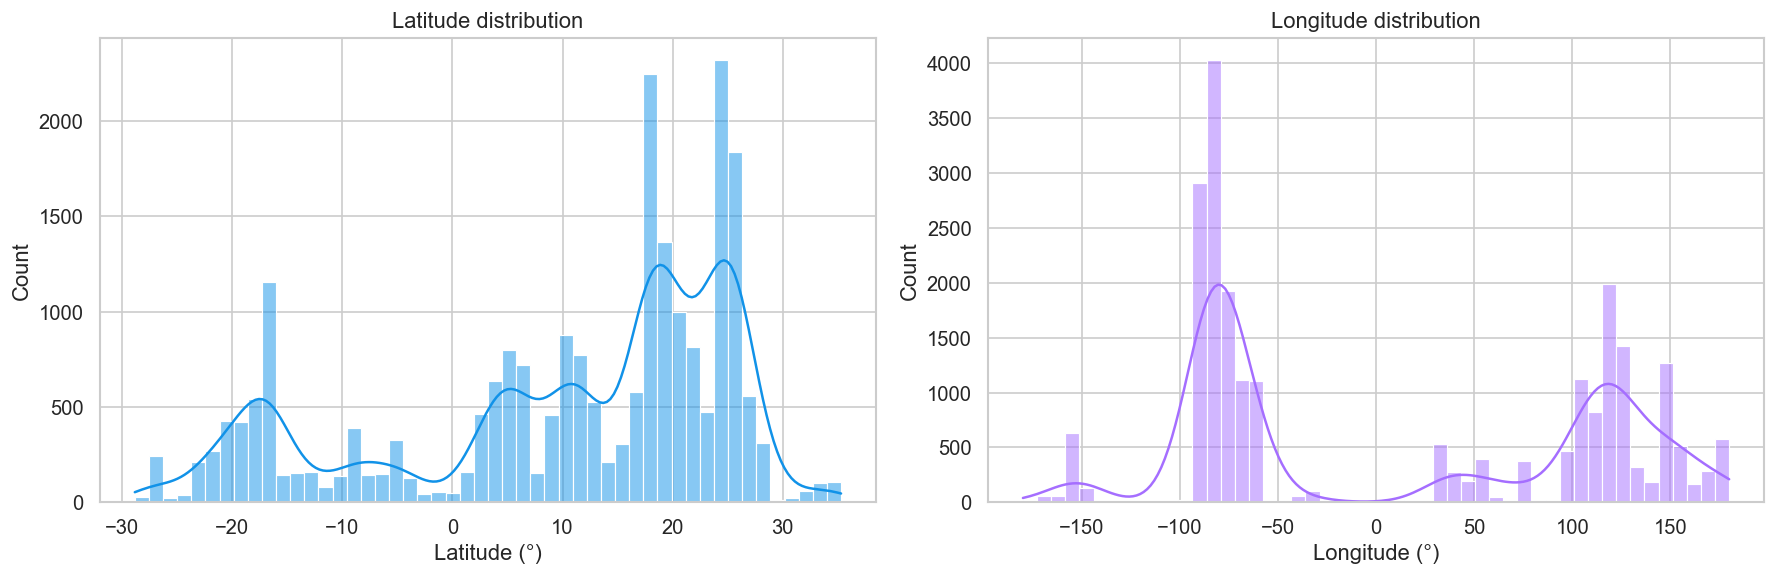

Most observations are concentrated between 30°S and 30°N — the tropical reef belt.


In [ ]:
# ── Lat / Lon histograms ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(coral['latitude'],  bins=50, kde=True, color=BLUE,   ax=axes[0])
axes[0].set_title('Latitude distribution')
axes[0].set_xlabel('Latitude (°)')

sns.histplot(coral['longitude'], bins=50, kde=True, color=PURPLE, ax=axes[1])
axes[1].set_title('Longitude distribution')
axes[1].set_xlabel('Longitude (°)')

plt.tight_layout()
plt.show()
print('Most observations are concentrated between 30°S and 30°N — the tropical reef belt.')

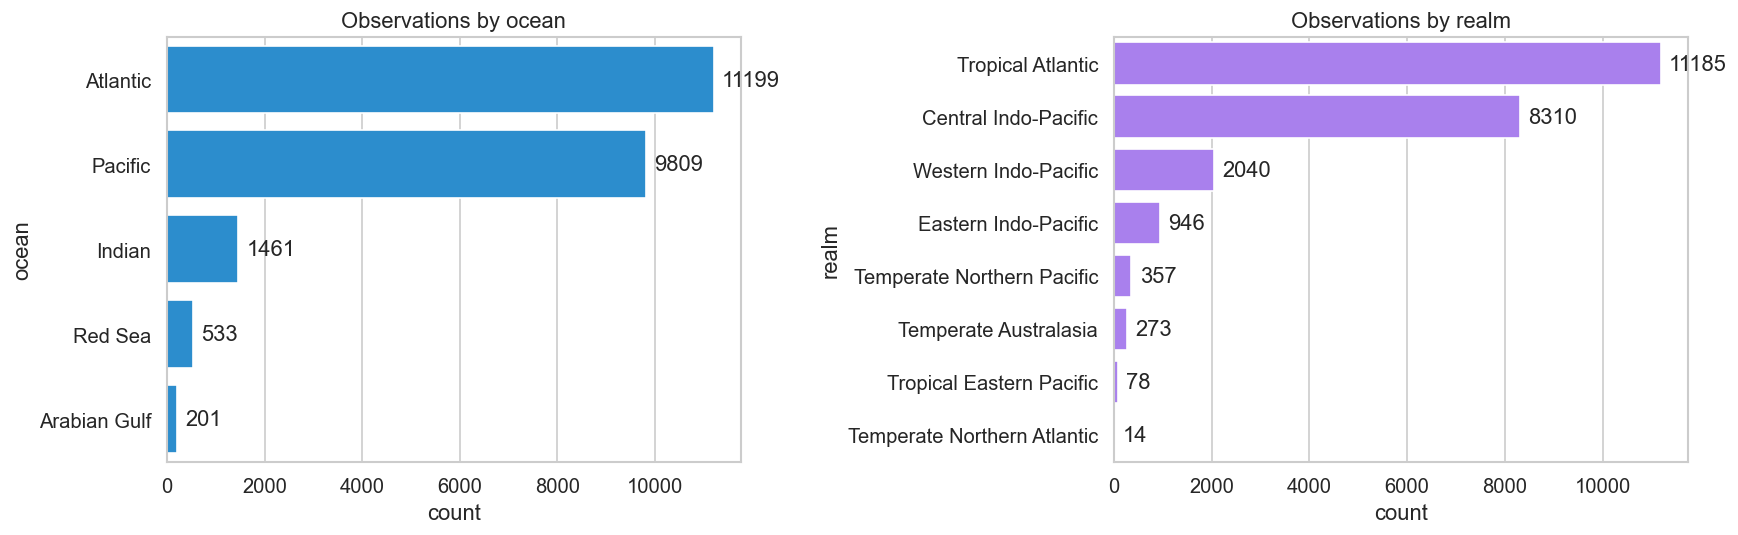

In [ ]:
# ── Ocean & Realm counts ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(y=coral['ocean'], order=coral['ocean'].value_counts().index,
              color=BLUE, ax=axes[0])
axes[0].set_title('Observations by ocean')
axes[0].bar_label(axes[0].containers[0], fmt='%d', padding=5)

sns.countplot(y=coral['realm'], order=coral['realm'].value_counts().index,
              color=PURPLE, ax=axes[1])
axes[1].set_title('Observations by realm')
axes[1].bar_label(axes[1].containers[0], fmt='%d', padding=5)

plt.tight_layout(pad=2)
plt.show()

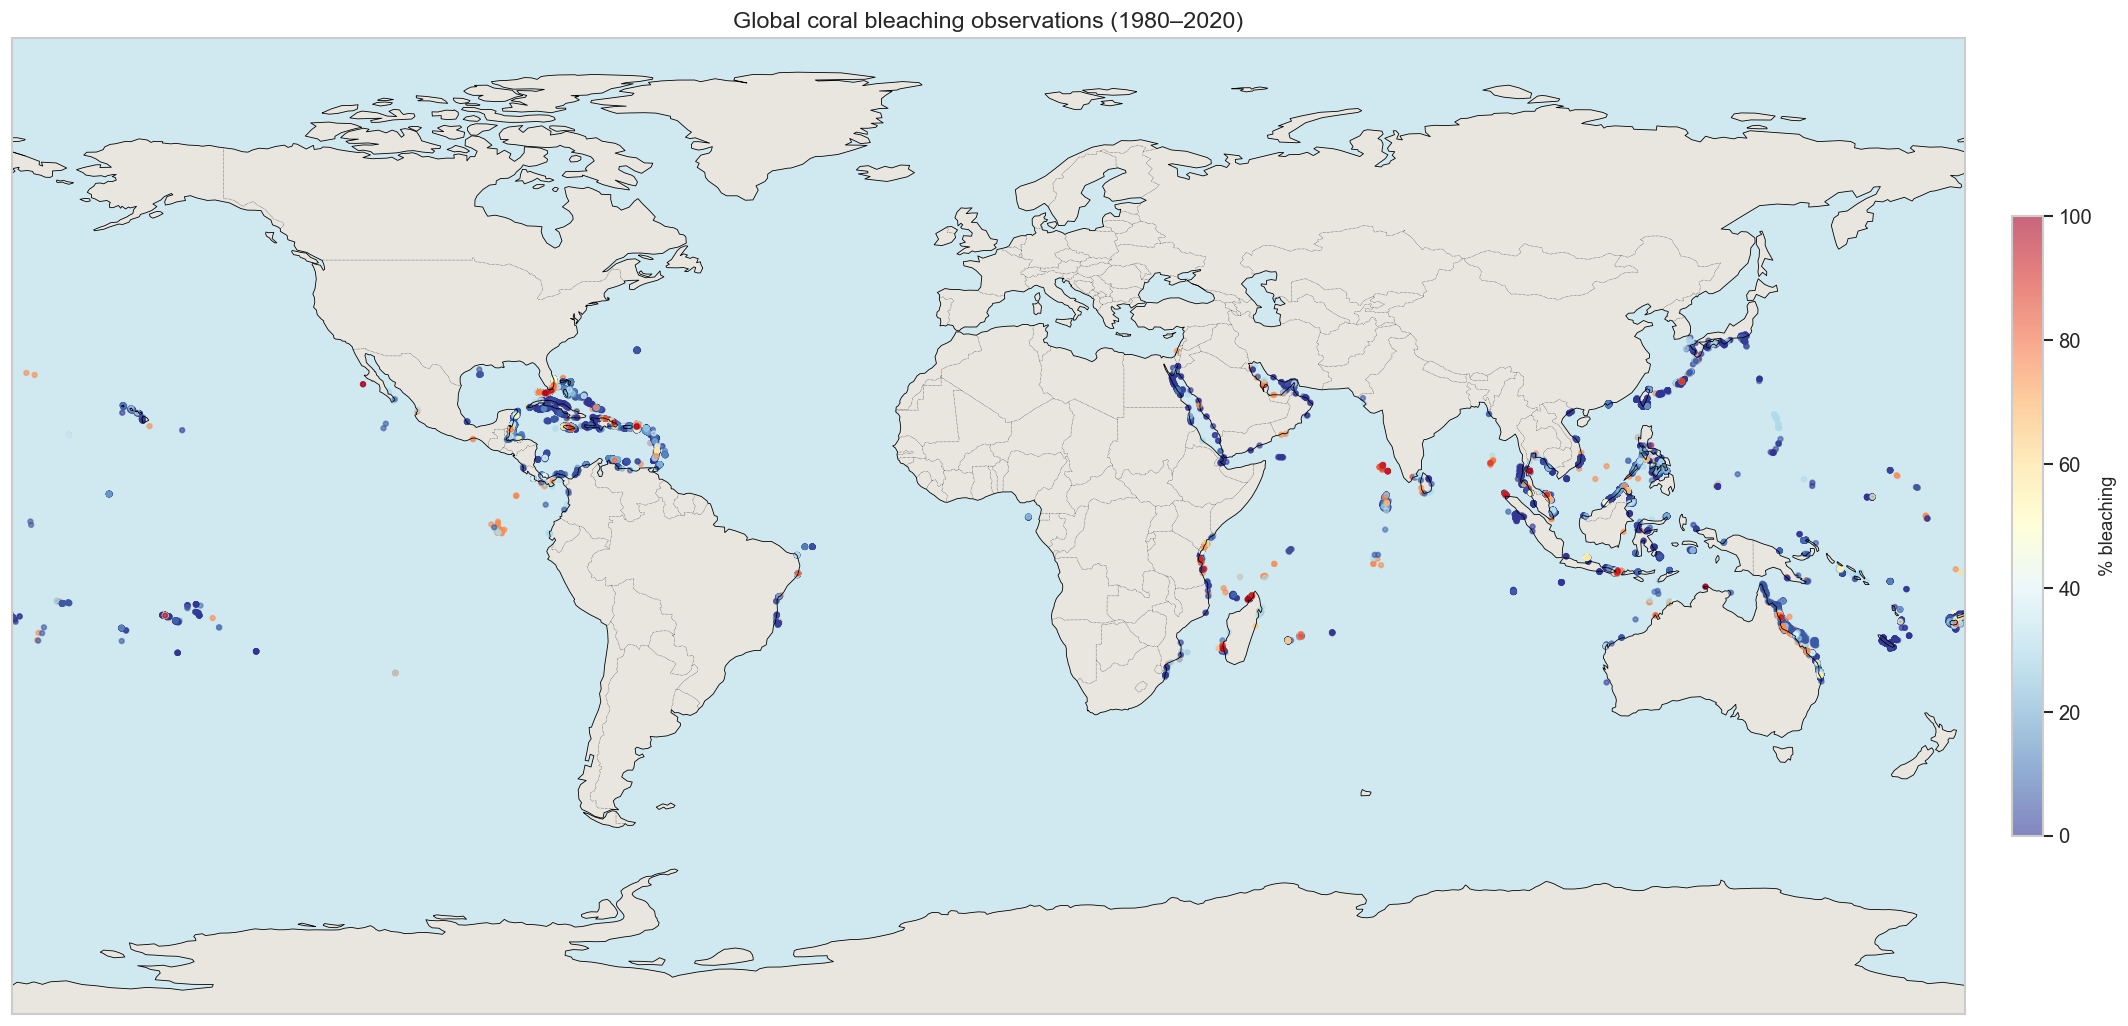

In [ ]:
# ── World map coloured by % bleaching ────────────────────────────────────
fig = plt.figure(figsize=(20, 9))
ax  = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.add_feature(cfeature.LAND,      facecolor='#e8e6df')
ax.add_feature(cfeature.OCEAN,     facecolor='#d0e8f0')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linestyle=':', linewidth=0.3)

sc = ax.scatter(
    coral['longitude'], coral['latitude'],
    c=coral['percent_bleaching'], cmap='RdYlBu_r',
    vmin=0, vmax=100, s=8, alpha=0.6,
    transform=ccrs.PlateCarree()
)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('% bleaching', fontsize=11)

ax.set_title('Global coral bleaching observations (1980–2020)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Target variable — `percent_bleaching`

Understanding the distribution of the target is essential before modelling. 
A heavily skewed or zero-inflated target affects which loss function and model family to use.

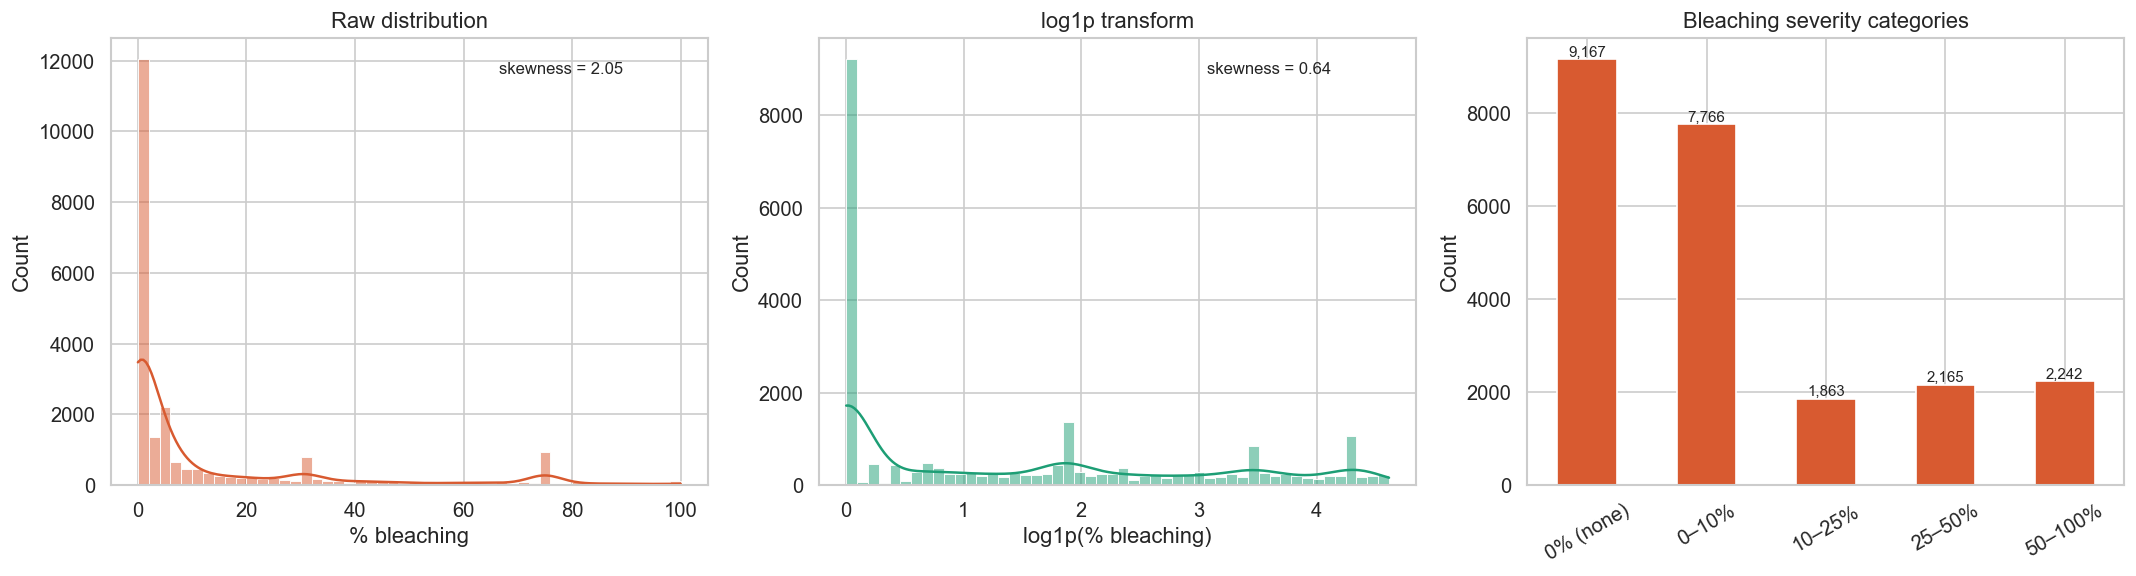

Zero bleaching: 39.5% of records
> 50% bleaching: 9.7% of records

⚠ Modelling note: the target is zero-inflated (39.5% zeros) and right-skewed.
  Consider: (1) log1p transform for regression, or
            (2) two-stage model — classify bleached/not, then regress severity.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw distribution
sns.histplot(coral['percent_bleaching'], bins=50, kde=True, color=CORAL, ax=axes[0])
axes[0].set_title('Raw distribution')
axes[0].set_xlabel('% bleaching')
skew_raw = coral['percent_bleaching'].skew()
axes[0].text(0.65, 0.92, f'skewness = {skew_raw:.2f}', transform=axes[0].transAxes, fontsize=10)

# log1p transform
log_vals = np.log1p(coral['percent_bleaching'])
sns.histplot(log_vals, bins=50, kde=True, color=TEAL, ax=axes[1])
axes[1].set_title('log1p transform')
axes[1].set_xlabel('log1p(% bleaching)')
skew_log = log_vals.skew()
axes[1].text(0.65, 0.92, f'skewness = {skew_log:.2f}', transform=axes[1].transAxes, fontsize=10)

# Binned severity
bins   = [-0.01, 0, 10, 25, 50, 100]
labels = ['0% (none)', '0–10%', '10–25%', '25–50%', '50–100%']
coral['bleaching_severity'] = pd.cut(coral['percent_bleaching'], bins=bins, labels=labels)
severity_counts = coral['bleaching_severity'].value_counts().sort_index()
severity_counts.plot(kind='bar', color=CORAL, ax=axes[2], rot=30)
axes[2].set_title('Bleaching severity categories')
axes[2].set_xlabel('')
axes[2].set_ylabel('Count')
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Zero bleaching: {(coral.percent_bleaching == 0).mean():.1%} of records')
print(f'> 50% bleaching: {(coral.percent_bleaching > 50).mean():.1%} of records')
print()
print('⚠ Modelling note: the target is zero-inflated (39.5% zeros) and right-skewed.')
print('  Consider: (1) log1p transform for regression, or')
print('            (2) two-stage model — classify bleached/not, then regress severity.')

## 4. Temporal trends

Coral bleaching events are strongly tied to El Niño / La Niña cycles and long-term ocean warming. 
Key years to watch: **1998** (strongest El Niño on record) and **2016** (second-strongest).

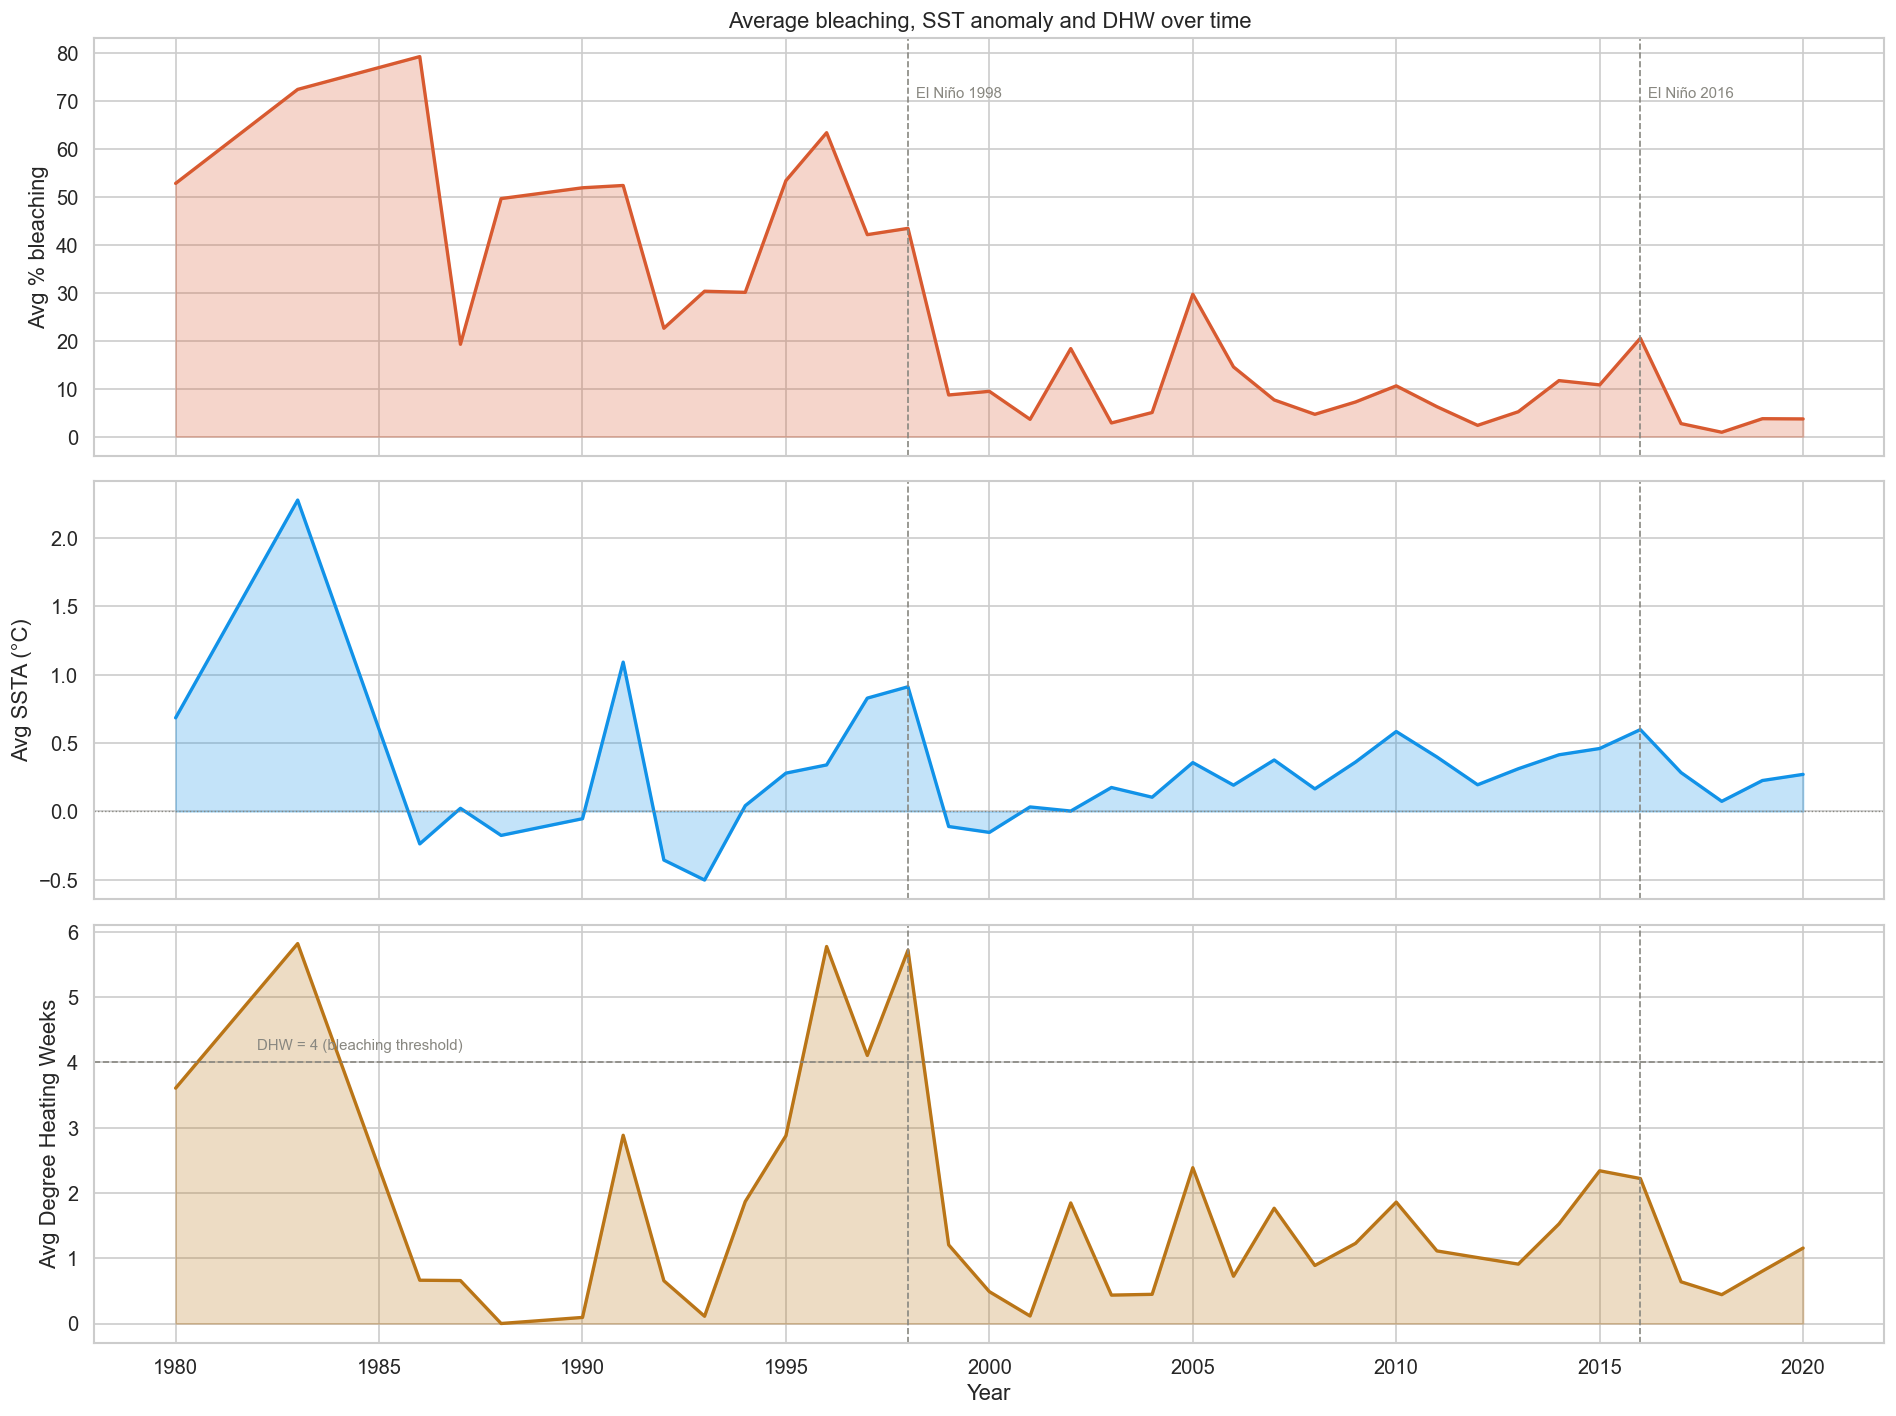

In [ ]:
yearly = coral.groupby('year').agg(
    avg_bleaching = ('percent_bleaching', 'mean'),
    n             = ('percent_bleaching', 'count'),
    avg_sst       = ('sst', 'mean'),
    avg_ssta      = ('ssta', 'mean'),
    avg_dhw       = ('tsa_dhw', 'mean')
).round(3)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Panel 1 — avg bleaching
axes[0].fill_between(yearly.index, yearly['avg_bleaching'], alpha=0.25, color=CORAL)
axes[0].plot(yearly.index, yearly['avg_bleaching'], color=CORAL, linewidth=2)
axes[0].axvline(1998, color=GRAY, linestyle='--', linewidth=1)
axes[0].axvline(2016, color=GRAY, linestyle='--', linewidth=1)
axes[0].text(1998.2, axes[0].get_ylim()[1]*0.85, 'El Niño 1998', fontsize=9, color=GRAY)
axes[0].text(2016.2, axes[0].get_ylim()[1]*0.85, 'El Niño 2016', fontsize=9, color=GRAY)
axes[0].set_ylabel('Avg % bleaching')
axes[0].set_title('Average bleaching, SST anomaly and DHW over time')

# Panel 2 — avg SSTA
axes[1].fill_between(yearly.index, yearly['avg_ssta'], alpha=0.25, color=BLUE)
axes[1].plot(yearly.index, yearly['avg_ssta'], color=BLUE, linewidth=2)
axes[1].axhline(0, color=GRAY, linewidth=0.8, linestyle=':')
axes[1].axvline(1998, color=GRAY, linestyle='--', linewidth=1)
axes[1].axvline(2016, color=GRAY, linestyle='--', linewidth=1)
axes[1].set_ylabel('Avg SSTA (°C)')

# Panel 3 — avg DHW
axes[2].fill_between(yearly.index, yearly['avg_dhw'], alpha=0.25, color=AMBER)
axes[2].plot(yearly.index, yearly['avg_dhw'], color=AMBER, linewidth=2)
axes[2].axhline(4, color=GRAY, linestyle='--', linewidth=1)
axes[2].text(1982, 4.2, 'DHW = 4 (bleaching threshold)', fontsize=9, color=GRAY)
axes[2].axvline(1998, color=GRAY, linestyle='--', linewidth=1)
axes[2].axvline(2016, color=GRAY, linestyle='--', linewidth=1)
axes[2].set_ylabel('Avg Degree Heating Weeks')
axes[2].set_xlabel('Year')

for ax in axes:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.show()

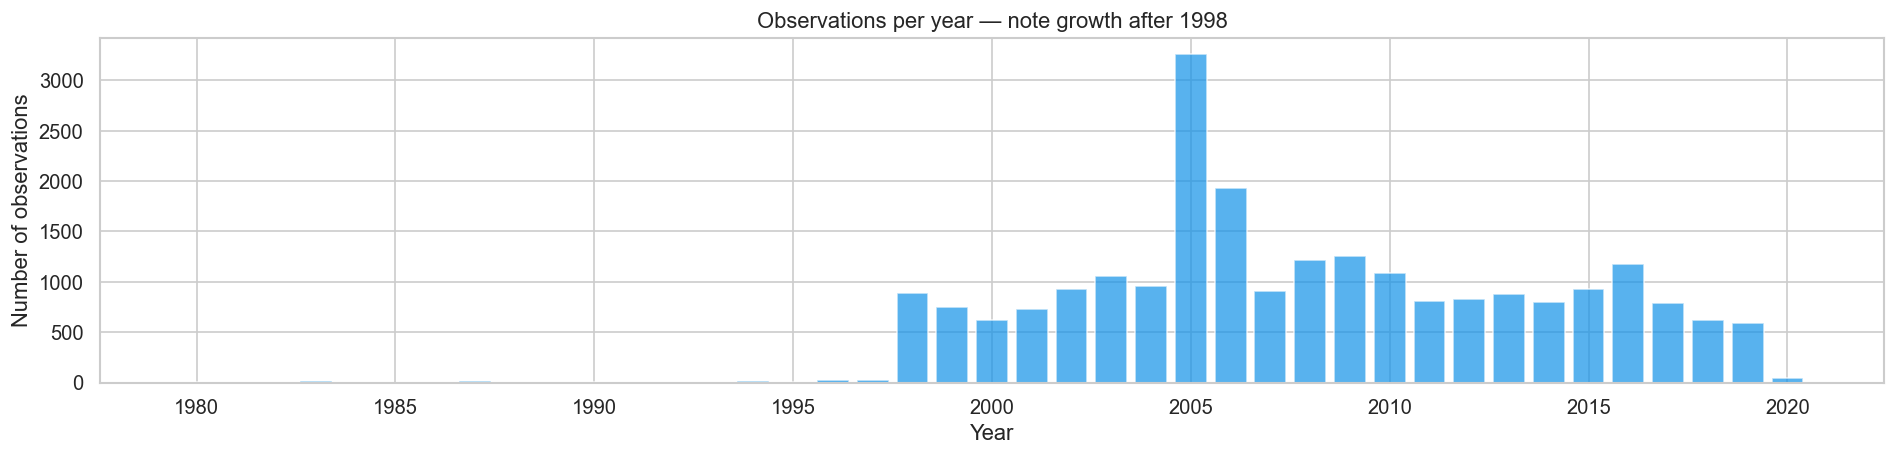

⚠ Sampling bias: data collection expanded dramatically from 1998 onwards.
  Pre-1998 averages are based on very few observations — interpret with caution.


In [ ]:
# ── Observation count per year (sampling bias check) ─────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(yearly.index, yearly['n'], color=BLUE, alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Number of observations')
ax.set_title('Observations per year — note growth after 1998')
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.tight_layout()
plt.show()
print('⚠ Sampling bias: data collection expanded dramatically from 1998 onwards.')
print('  Pre-1998 averages are based on very few observations — interpret with caution.')

## 5. Environmental drivers

### 5a. Degree Heating Weeks (DHW) — the most important feature

DHW measures the accumulation of thermal stress above a baseline. 
In coral biology, **DHW ≥ 4** triggers bleaching; **DHW ≥ 8** causes mortality. 
`tsa_dhw` and `ssta_dhw` are the two strongest predictors in this dataset (r ≈ 0.28).

                mean  median  count
dhw_bin                            
0 (no stress)   7.67    0.36  15013
0–4 DHW        16.75    5.50   5443
4–8 DHW        33.54   26.11   1987
8–12 DHW       44.54   49.23    430
>12 DHW        31.22   18.41    330


/var/folders/yz/shh48k7s5kg3qtp0x9hzjb6c0000gn/T/ipykernel_42376/629479537.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dhw_stats = coral.groupby('dhw_bin')['percent_bleaching'].agg(['mean','median','count'])


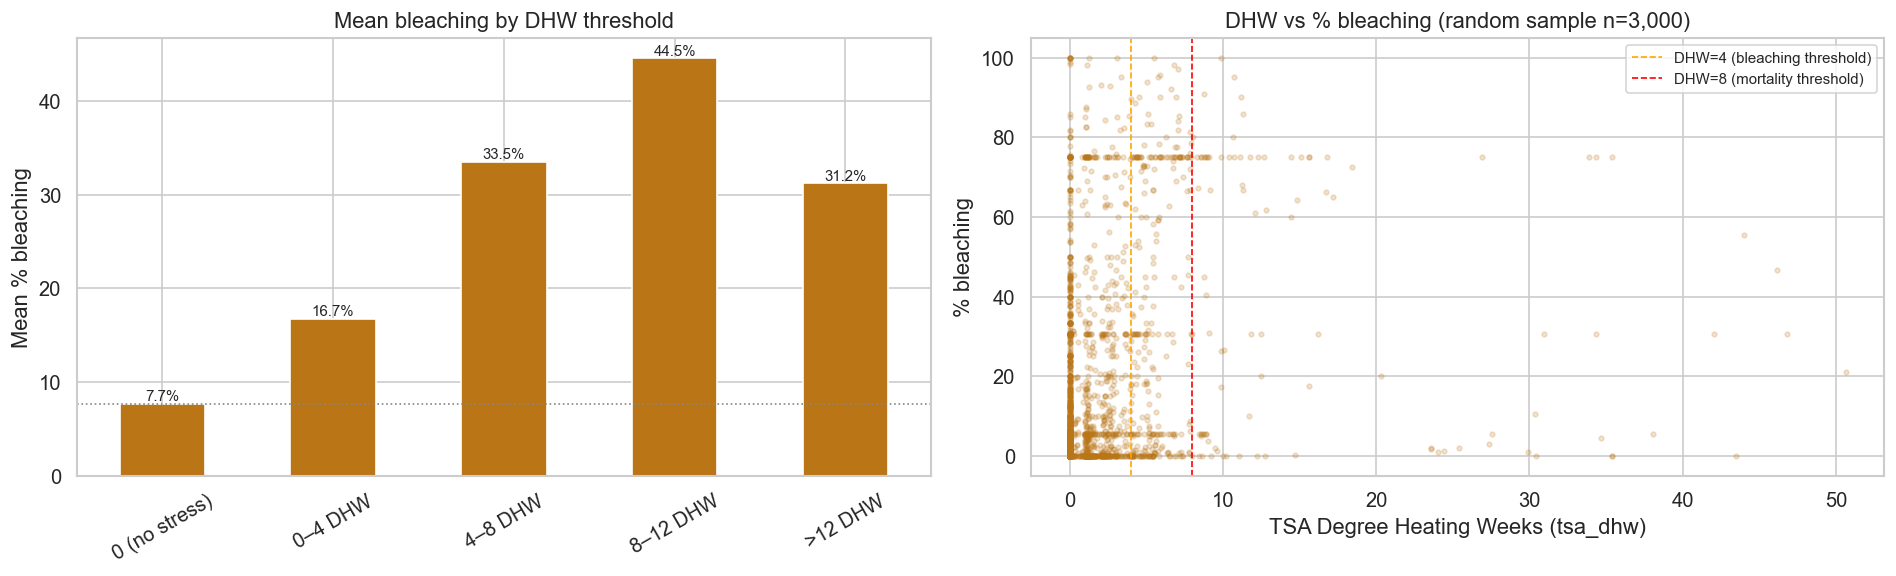

In [ ]:
coral['dhw_bin'] = pd.cut(
    coral['tsa_dhw'],
    bins=[-0.1, 0, 4, 8, 12, 60],
    labels=['0 (no stress)', '0–4 DHW', '4–8 DHW', '8–12 DHW', '>12 DHW']
)

dhw_stats = coral.groupby('dhw_bin')['percent_bleaching'].agg(['mean','median','count'])
print(dhw_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean bleaching per DHW bin
dhw_stats['mean'].plot(kind='bar', color=AMBER, ax=axes[0], rot=30)
axes[0].set_title('Mean bleaching by DHW threshold')
axes[0].set_ylabel('Mean % bleaching')
axes[0].set_xlabel('')
axes[0].axhline(dhw_stats['mean'].iloc[0], color=GRAY, linestyle=':', linewidth=1)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Scatter: DHW vs bleaching
sample = coral.sample(3000, random_state=42)
axes[1].scatter(sample['tsa_dhw'], sample['percent_bleaching'],
                alpha=0.2, s=8, color=AMBER)
axes[1].set_xlabel('TSA Degree Heating Weeks (tsa_dhw)')
axes[1].set_ylabel('% bleaching')
axes[1].set_title('DHW vs % bleaching (random sample n=3,000)')
axes[1].axvline(4,  color='orange', linestyle='--', linewidth=1, label='DHW=4 (bleaching threshold)')
axes[1].axvline(8,  color='red',    linestyle='--', linewidth=1, label='DHW=8 (mortality threshold)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 5b. Sea Surface Temperature Anomaly (SSTA) vs bleaching

/var/folders/yz/shh48k7s5kg3qtp0x9hzjb6c0000gn/T/ipykernel_42376/1725134906.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ssta_stats = coral.groupby('ssta_bin')['percent_bleaching'].mean()


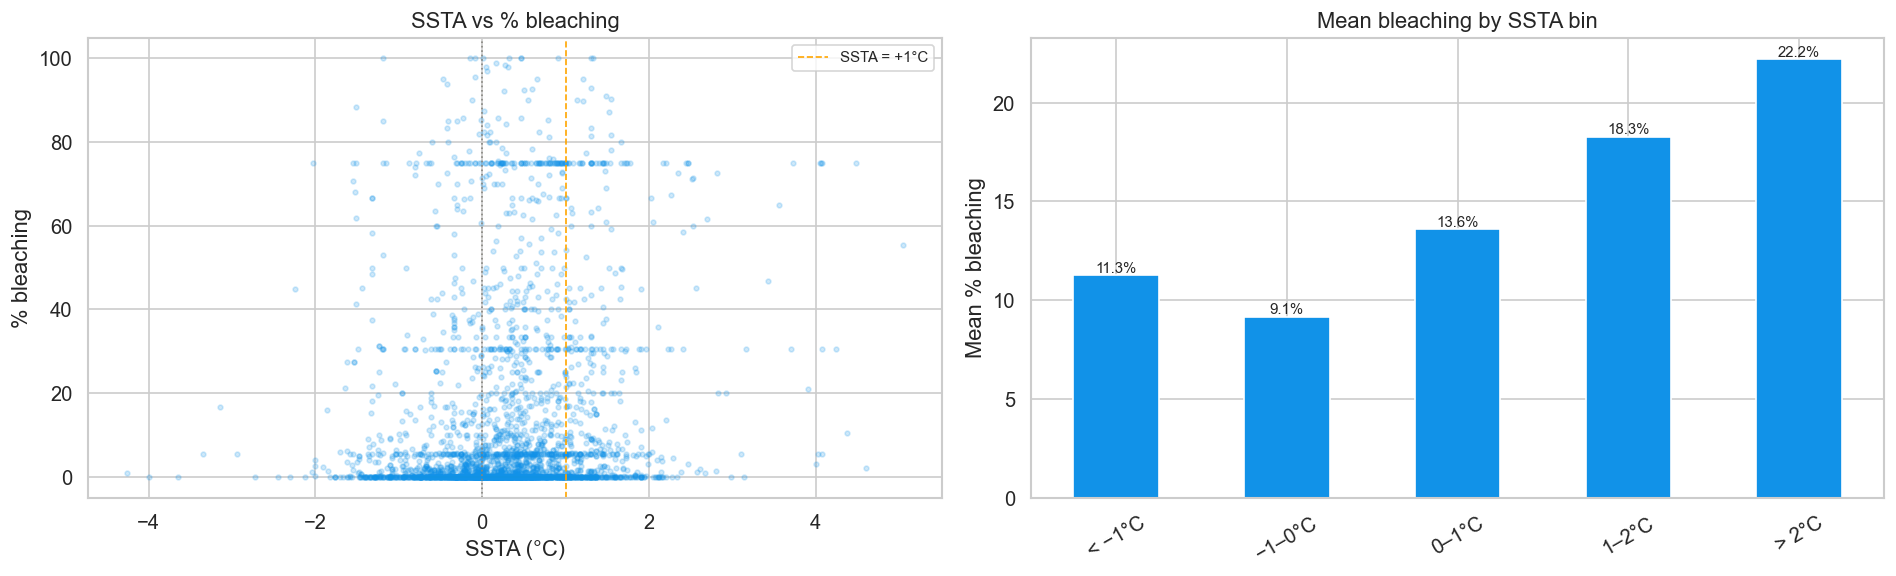

Bleaching rises sharply above SSTA > +1°C — consistent with the literature.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter SSTA vs bleaching
sample = coral.sample(3000, random_state=42)
axes[0].scatter(sample['ssta'], sample['percent_bleaching'],
                alpha=0.2, s=8, color=BLUE)
axes[0].set_xlabel('SSTA (°C)')
axes[0].set_ylabel('% bleaching')
axes[0].set_title('SSTA vs % bleaching')
axes[0].axvline(0, color=GRAY, linestyle=':', linewidth=1)
axes[0].axvline(1, color='orange', linestyle='--', linewidth=1, label='SSTA = +1°C')
axes[0].legend(fontsize=9)

# SSTA binned
coral['ssta_bin'] = pd.cut(coral['ssta'], bins=[-5,-1,0,1,2,6],
                            labels=['< −1°C','−1–0°C','0–1°C','1–2°C','> 2°C'])
ssta_stats = coral.groupby('ssta_bin')['percent_bleaching'].mean()
ssta_stats.plot(kind='bar', color=BLUE, ax=axes[1], rot=30)
axes[1].set_title('Mean bleaching by SSTA bin')
axes[1].set_ylabel('Mean % bleaching')
axes[1].set_xlabel('')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print('Bleaching rises sharply above SSTA > +1°C — consistent with the literature.')

### 5c. Depth effect

/var/folders/yz/shh48k7s5kg3qtp0x9hzjb6c0000gn/T/ipykernel_42376/2376468604.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  depth_stats = coral.groupby('depth_bucket')['percent_bleaching'].agg(['mean','count'])


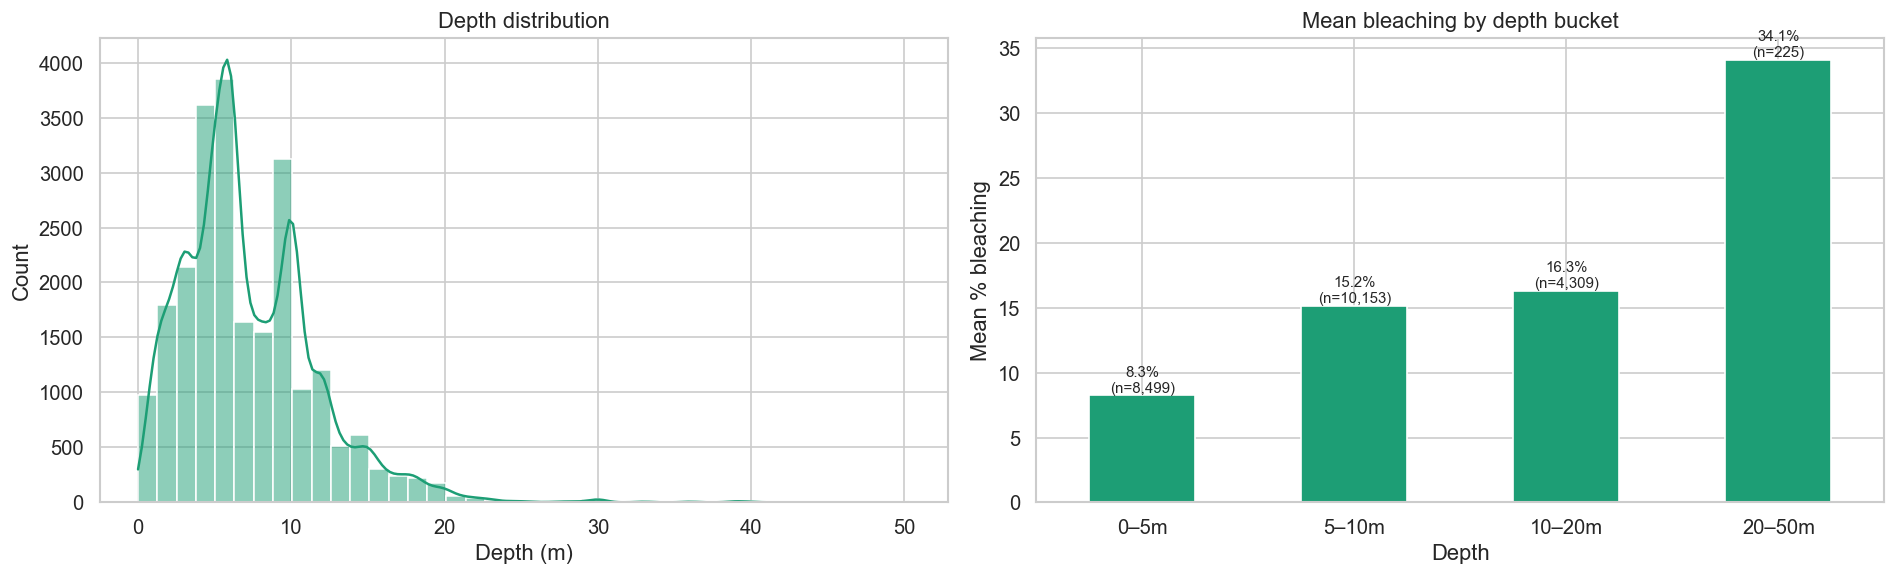

Bleaching increases with depth — deeper corals face accumulated stress
and have less access to cooler surface mixing during heat events.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Depth histogram
sns.histplot(coral['depth_m'], bins=40, kde=True, color=TEAL, ax=axes[0])
axes[0].set_title('Depth distribution')
axes[0].set_xlabel('Depth (m)')

# Mean bleaching by depth bucket
coral['depth_bucket'] = pd.cut(
    coral['depth_m'], bins=[0, 5, 10, 20, 50],
    labels=['0–5m', '5–10m', '10–20m', '20–50m']
)
depth_stats = coral.groupby('depth_bucket')['percent_bleaching'].agg(['mean','count'])
depth_stats['mean'].plot(kind='bar', color=TEAL, ax=axes[1], rot=0)
axes[1].set_title('Mean bleaching by depth bucket')
axes[1].set_ylabel('Mean % bleaching')
axes[1].set_xlabel('Depth')
for i, (p, row) in enumerate(zip(axes[1].patches, depth_stats.itertuples())):
    axes[1].annotate(f'{p.get_height():.1f}%\n(n={row.count:,})',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Bleaching increases with depth — deeper corals face accumulated stress')
print('and have less access to cooler surface mixing during heat events.')

### 5d. Depth × SSTA interaction

Mean % bleaching by depth × SSTA bin:
ssta          SSTA ≤ 0  0–1°C  1–2°C  > 2°C
depth_bucket                               
0–5m               5.1    9.0   13.0   13.9
5–10m             11.3   15.6   21.0   23.3
10–20m            14.0   16.2   21.0   32.7
20–50m            14.4   41.8   35.5   38.0


/var/folders/yz/shh48k7s5kg3qtp0x9hzjb6c0000gn/T/ipykernel_42376/1469824502.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = coral.pivot_table(


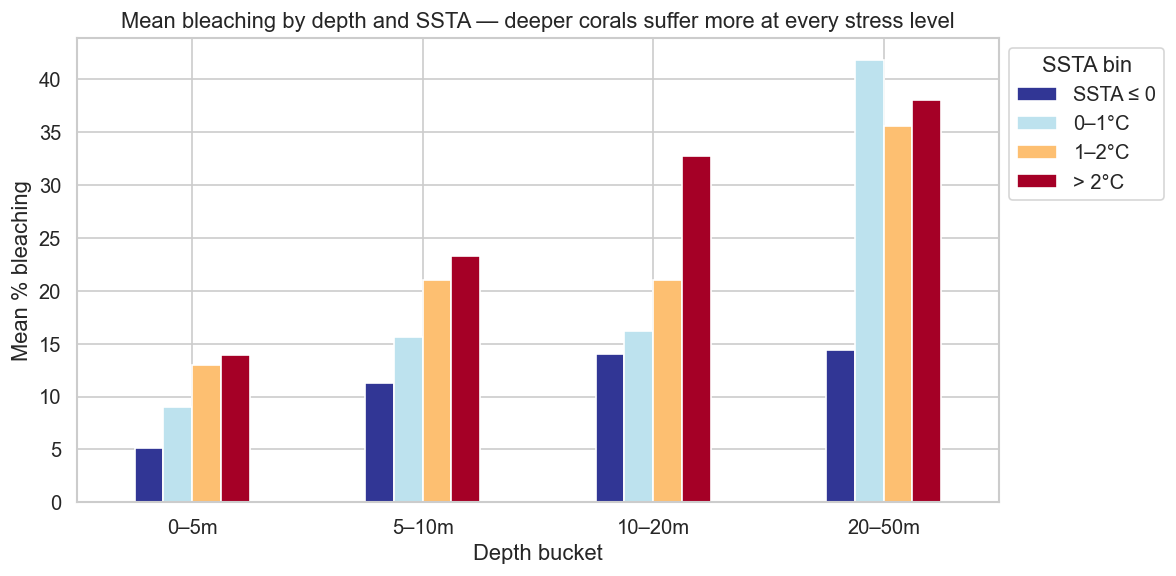

In [ ]:
# Does the depth effect depend on thermal stress?
pivot = coral.pivot_table(
    index='depth_bucket',
    columns=pd.cut(coral['ssta'], bins=[-5,0,1,2,6],
                   labels=['SSTA ≤ 0','0–1°C','1–2°C','> 2°C']),
    values='percent_bleaching',
    aggfunc='mean'
).round(1)

print('Mean % bleaching by depth × SSTA bin:')
print(pivot)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, rot=0, colormap='RdYlBu_r')
ax.set_title('Mean bleaching by depth and SSTA — deeper corals suffer more at every stress level')
ax.set_xlabel('Depth bucket')
ax.set_ylabel('Mean % bleaching')
ax.legend(title='SSTA bin', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## 6. Categorical breakdowns

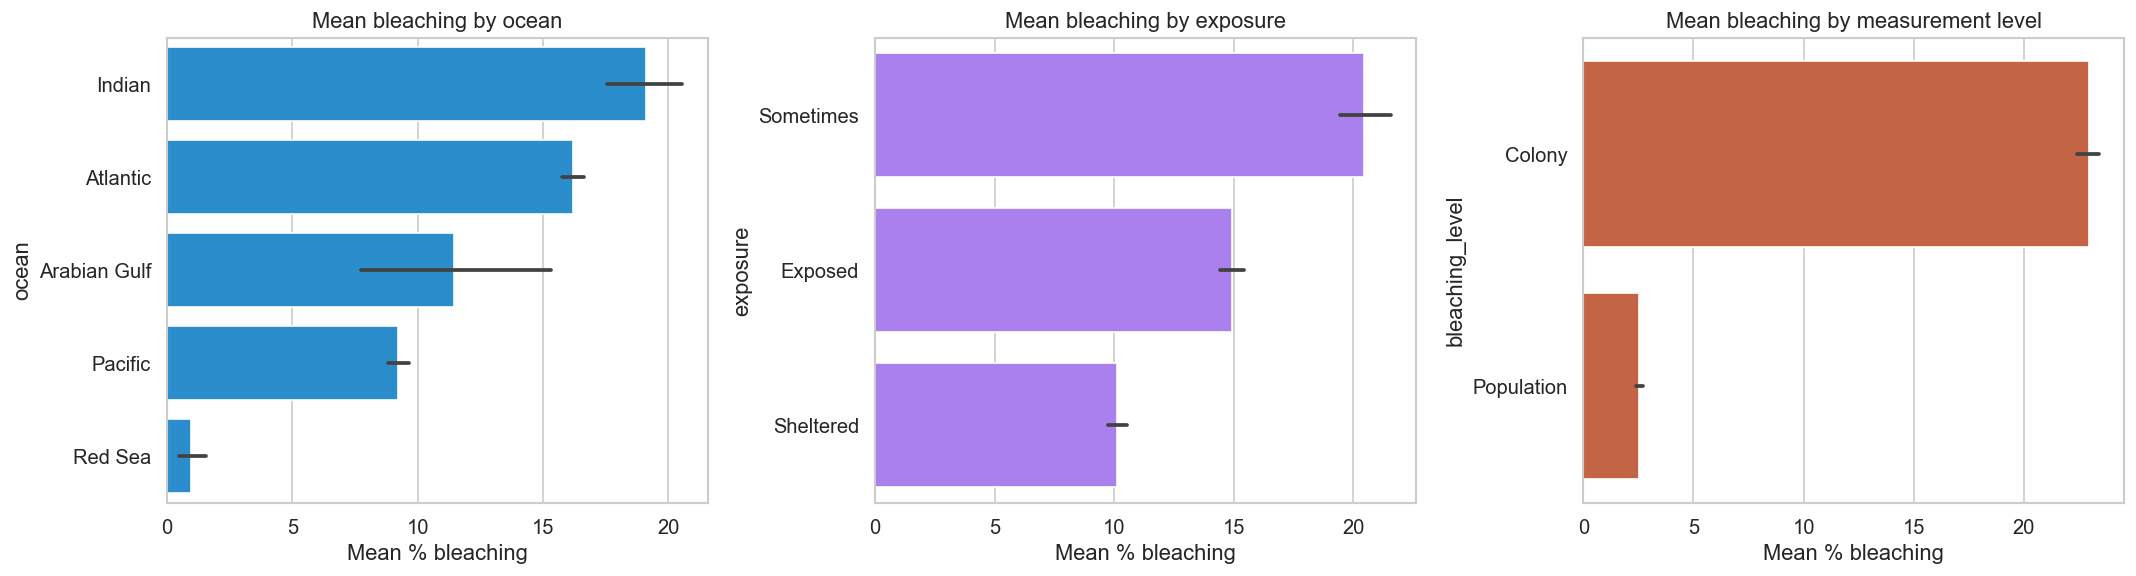

Colony-level measurements average 22.9% vs 2.5% for Population-level.
This reflects methodology: colony studies target visibly stressed reefs,
while population surveys include healthy areas. bleaching_level is an important control variable.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By ocean
ocean_order = coral.groupby('ocean')['percent_bleaching'].mean().sort_values(ascending=False).index
sns.barplot(data=coral, y='ocean', x='percent_bleaching',
            order=ocean_order, color=BLUE, ax=axes[0],
            estimator='mean', errorbar='ci')
axes[0].set_title('Mean bleaching by ocean')
axes[0].set_xlabel('Mean % bleaching')

# By exposure
exposure_order = coral.groupby('exposure')['percent_bleaching'].mean().sort_values(ascending=False).index
sns.barplot(data=coral, y='exposure', x='percent_bleaching',
            order=exposure_order, color=PURPLE, ax=axes[1],
            estimator='mean', errorbar='ci')
axes[1].set_title('Mean bleaching by exposure')
axes[1].set_xlabel('Mean % bleaching')

# By bleaching level (Colony vs Population)
sns.barplot(data=coral, y='bleaching_level', x='percent_bleaching',
            color=CORAL, ax=axes[2], estimator='mean', errorbar='ci')
axes[2].set_title('Mean bleaching by measurement level')
axes[2].set_xlabel('Mean % bleaching')

plt.tight_layout()
plt.show()

print('Colony-level measurements average 22.9% vs 2.5% for Population-level.')
print('This reflects methodology: colony studies target visibly stressed reefs,')
print('while population surveys include healthy areas. bleaching_level is an important control variable.')

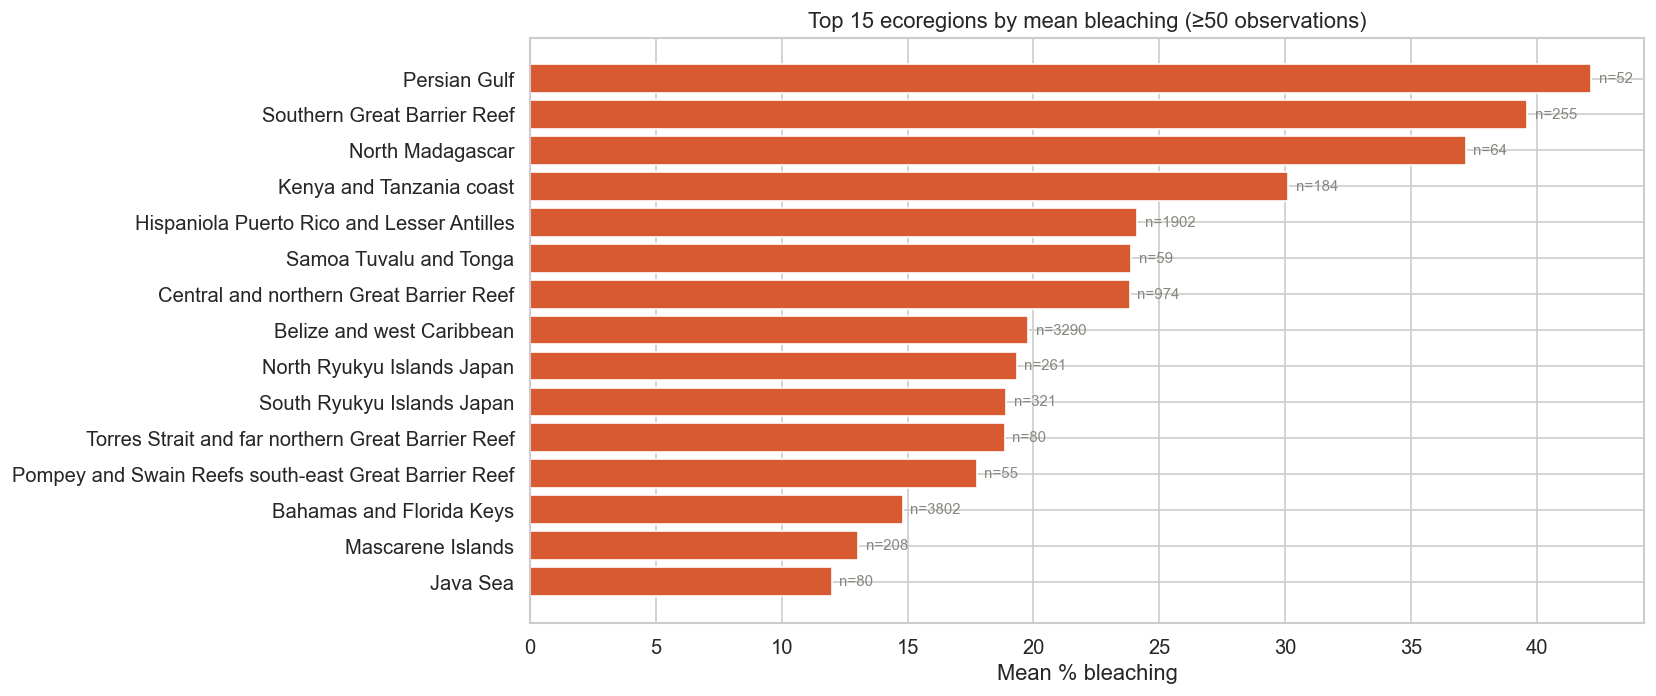

In [ ]:
# ── Top 15 ecoregions by mean bleaching (min 50 observations) ────────────
eco_stats = coral.groupby('ecoregion').agg(
    mean_bleaching=('percent_bleaching','mean'),
    n=('percent_bleaching','count')
).query('n >= 50').sort_values('mean_bleaching', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(eco_stats.index[::-1], eco_stats['mean_bleaching'][::-1], color=CORAL)
for bar, n in zip(bars, eco_stats['n'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'n={n}', va='center', fontsize=9, color=GRAY)
ax.set_title('Top 15 ecoregions by mean bleaching (≥50 observations)')
ax.set_xlabel('Mean % bleaching')
plt.tight_layout()
plt.show()

## 7. Correlation analysis & feature insights for modelling

This section identifies which features are most relevant for the predictive model.

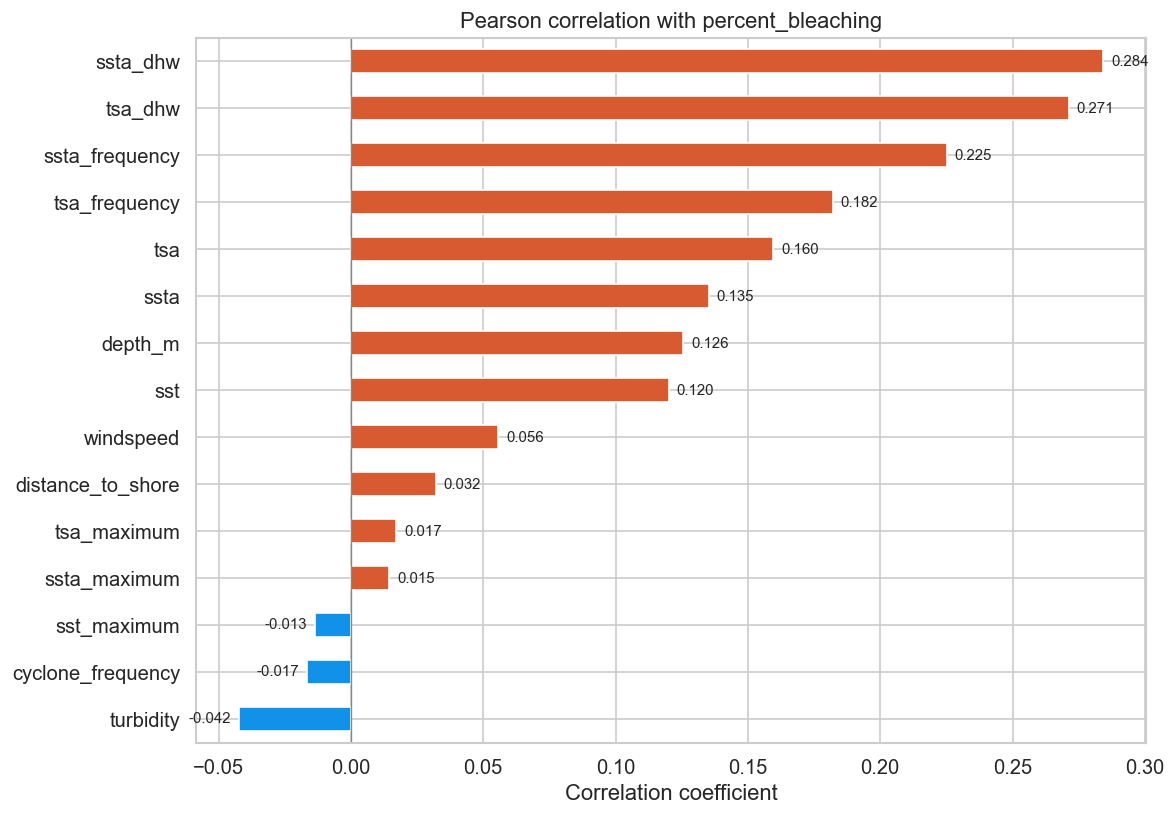

In [ ]:
# ── Bar chart: correlations with target ──────────────────────────────────
num_cols = [
    'sst','sst_maximum','ssta','ssta_maximum','ssta_frequency',
    'tsa','tsa_maximum','tsa_frequency','ssta_dhw','tsa_dhw',
    'depth_m','turbidity','distance_to_shore','windspeed','cyclone_frequency'
]
corrs = coral[num_cols + ['percent_bleaching']].corr()['percent_bleaching'] \
            .drop('percent_bleaching').sort_values()

colors = [CORAL if v > 0 else BLUE for v in corrs]

fig, ax = plt.subplots(figsize=(10, 7))
corrs.plot(kind='barh', color=colors, ax=ax)
ax.axvline(0, color=GRAY, linewidth=0.8)
ax.set_title('Pearson correlation with percent_bleaching')
ax.set_xlabel('Correlation coefficient')
for bar, val in zip(ax.patches, corrs):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

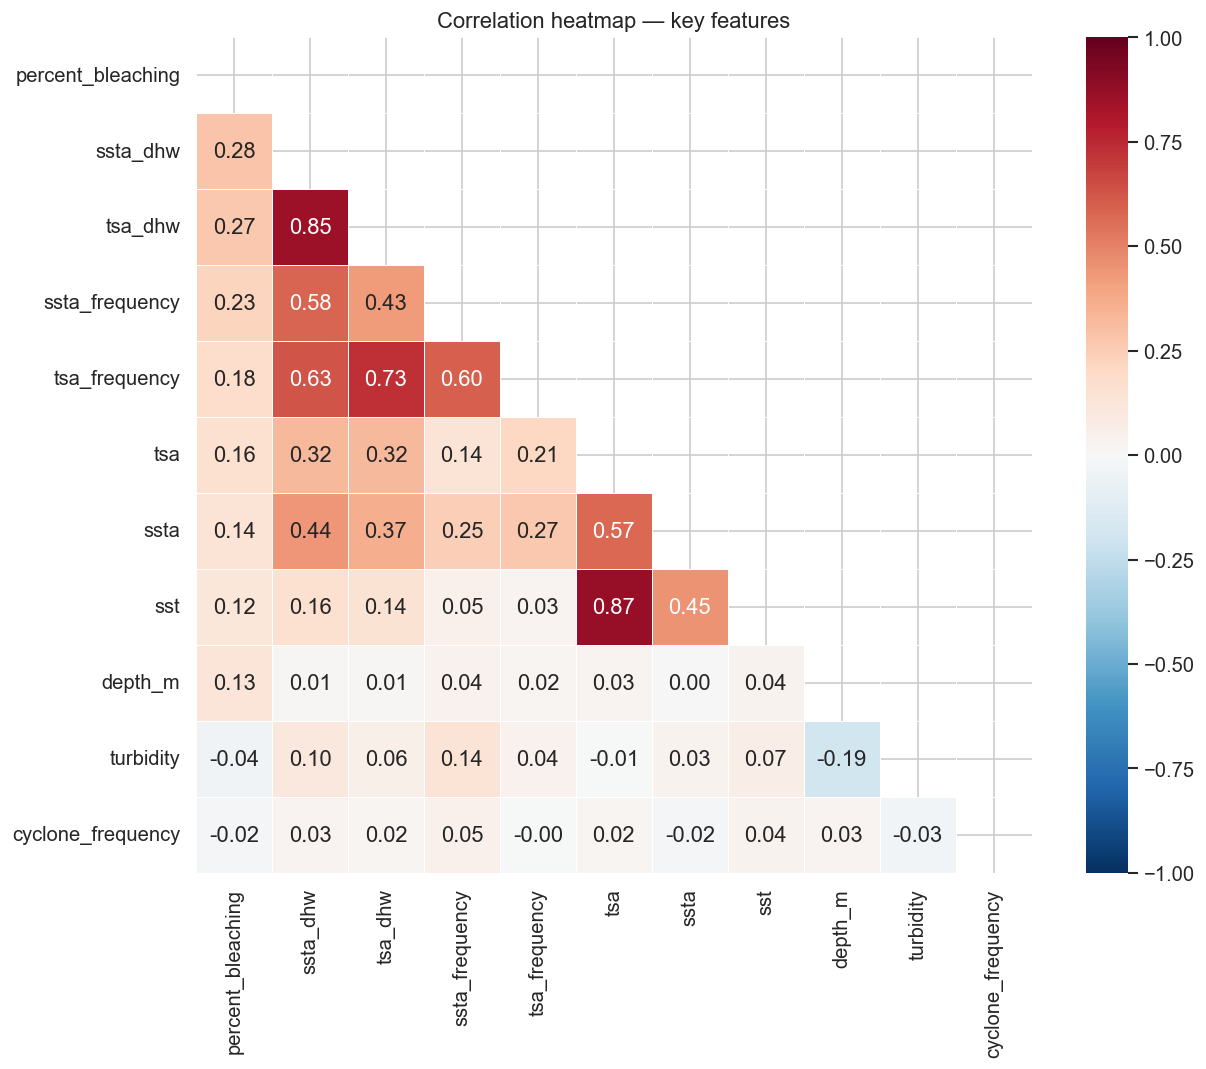

In [ ]:
# ── Heatmap of key features ───────────────────────────────────────────────
key_feats = [
    'percent_bleaching','ssta_dhw','tsa_dhw','ssta_frequency','tsa_frequency',
    'tsa','ssta','sst','depth_m','turbidity','cyclone_frequency'
]
corr_matrix = coral[key_feats].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation heatmap — key features')
plt.tight_layout()
plt.show()

### Feature selection summary for modelling

| Feature | r with target | Domain rationale |
|---------|--------------|------------------|
| `ssta_dhw` | 0.28 | Accumulated thermal stress — primary bleaching driver |
| `tsa_dhw` | 0.27 | Similar to ssta_dhw, alternative thermal stress metric |
| `ssta_frequency` | 0.23 | How often anomalies occur — chronic vs acute stress |
| `tsa_frequency` | 0.18 | Same, TSA-based |
| `tsa` | 0.16 | Instantaneous thermal anomaly |
| `ssta` | 0.14 | Sea surface temperature anomaly |
| `depth_m` | 0.13 | Proxy for light and water movement |
| `sst` | 0.12 | Absolute temperature (°C) |
| `bleaching_level` | — | Strong categorical confounder — always include |

**Recommended approach for the model:**
- Use `ssta_dhw` + `tsa_dhw` as primary features (not both — check multicollinearity)
- Include `ssta_frequency`, `depth_m`, `sst`, `exposure`, `bleaching_level` as secondary features
- Omit `turbidity`, `cyclone_frequency`, `distance_to_shore` (near-zero correlation, potential noise)
- Consider `log1p` transform of the target, or a two-stage model to handle the 39.5% zeros